# Chapter 4 — Regression and Prediction
## Practical Statistics for Data Scientists (2nd Edition)

Chapter ini mengikuti struktur Chapter 4 edisi ke-2: **Simple Linear Regression, Multiple Linear Regression, Prediction Using Regression, Factor Variables, Correlated Predictors, Regression Diagnostics, Polynomial and Spline Regression, dan Generalized Additive Models (GAM)**. citeturn0search3

**Catatan data:** notebook menggunakan data sintetis untuk menjaga reproduktibilitas dan memperjelas konsep. Hasil numerik bukan klaim sebagai hasil dataset buku.



## 1. Tujuan Pembelajaran
Setelah chapter ini, kita dapat:
- membangun dan menginterpretasikan simple serta multiple linear regression;
- memahami fitted values, residuals, least squares, dan koefisien;
- mengevaluasi model dengan MAE, RMSE, R², dan cross-validation;
- memahami dummy variables, multicollinearity, confounding, dan interaction;
- melakukan regression diagnostics;
- menggunakan polynomial, spline, dan GAM untuk hubungan nonlinear;
- memahami hubungan regression dengan supervised learning/ML/DL.



In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"]=(9,5)



## 2. Simple Linear Regression
### The Regression Equation
Simple linear regression memodelkan hubungan satu predictor X dan response Y:

$$Y=b_0+b_1X+\epsilon$$

**b₀** adalah intercept dan **b₁** adalah slope. Regression tidak hanya mengukur asosiasi, tetapi memberikan persamaan yang dapat digunakan untuk prediksi. citeturn0search3



In [2]:
n=180
x=np.linspace(1,20,n)
y=42+3.8*x+np.random.normal(0,7,n)
df=pd.DataFrame({"Exposure":x,"Sales":y})
m=LinearRegression().fit(df[["Exposure"]],df.Sales)
df["Fitted"]=m.predict(df[["Exposure"]]); df["Residual"]=df.Sales-df.Fitted
print(f"Intercept = {m.intercept_:.3f}")
print(f"Slope     = {m.coef_[0]:.3f}")



Intercept = 40.265
Slope     = 3.951


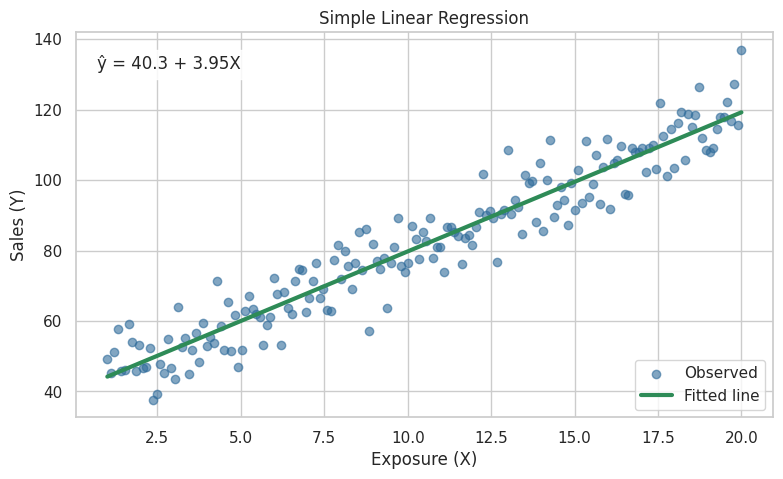

Caption — Garis hijau adalah nilai prediksi model. Slope positif menunjukkan hubungan positif pada data sintetis.


In [3]:
fig,ax=plt.subplots()
ax.scatter(df.Exposure,df.Sales,alpha=.6,color="#2F6B9A",label="Observed")
ax.plot(df.Exposure,df.Fitted,color="#2E8B57",lw=3,label="Fitted line")
ax.set(title="Simple Linear Regression",xlabel="Exposure (X)",ylabel="Sales (Y)")
ax.text(.03,.94,f"ŷ = {m.intercept_:.1f} + {m.coef_[0]:.2f}X",transform=ax.transAxes,
        va="top",bbox=dict(facecolor="white",alpha=.85)); ax.legend(); plt.show()
print("Caption — Garis hijau adalah nilai prediksi model. Slope positif menunjukkan hubungan positif pada data sintetis.")



### Fitted Values, Residuals, dan Least Squares
Fitted value adalah nilai yang diprediksi model. Residual adalah:
$$e_i=y_i-\hat y_i$$

OLS memilih koefisien yang meminimalkan:
$$\sum_i(y_i-\hat y_i)^2$$



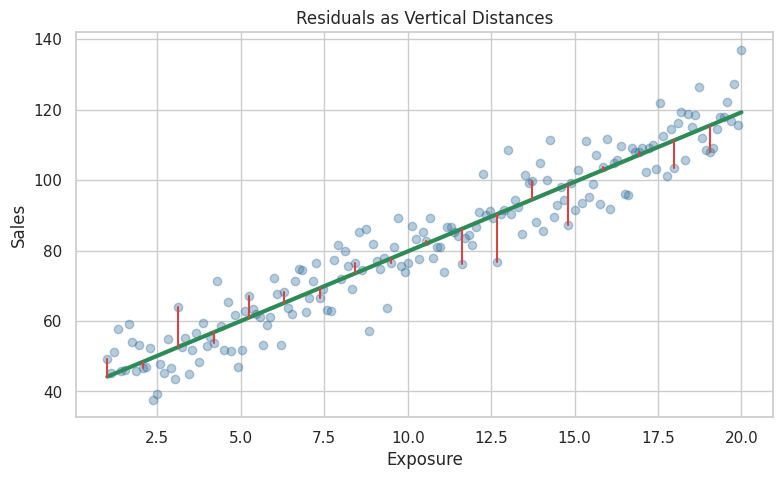

Caption — Garis merah menunjukkan residual, yaitu jarak vertikal antara observasi aktual dan fitted value.


In [4]:
fig,ax=plt.subplots()
ax.scatter(df.Exposure,df.Sales,alpha=.35,color="#2F6B9A")
ax.plot(df.Exposure,df.Fitted,color="#2E8B57",lw=3)
for _,r in df.iloc[::10].iterrows():
    ax.plot([r.Exposure,r.Exposure],[r.Sales,r.Fitted],color="#D64545",lw=1.5)
ax.set(title="Residuals as Vertical Distances",xlabel="Exposure",ylabel="Sales"); plt.show()
print("Caption — Garis merah menunjukkan residual, yaitu jarak vertikal antara observasi aktual dan fitted value.")



In [5]:
ols=smf.ols("Sales ~ Exposure",data=df).fit()
print(ols.summary().tables[1])
print(f"R²={ols.rsquared:.4f}; RMSE={np.sqrt(np.mean(ols.resid**2)):.3f}")



                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     40.2646      1.061     37.962      0.000      38.172      42.358
Exposure       3.9505      0.089     44.176      0.000       3.774       4.127
R²=0.9164; RMSE=6.580


## 3. Prediction Versus Explanation (Profiling)
Regression dapat digunakan untuk **prediction** maupun **explanation/profiling**. Koefisien regression bukan otomatis bukti kausalitas; klaim kausal membutuhkan desain dan asumsi yang sesuai.



## 4. Multiple Linear Regression
Model dengan beberapa predictor:
$$Y=b_0+b_1X_1+...+b_pX_p+\epsilon$$
Koefisien dibaca sebagai perubahan rata-rata Y ketika satu predictor berubah satu unit dengan predictor lain dalam model dikendalikan.



In [6]:
rng=np.random.default_rng(42); n=700
house=pd.DataFrame({
"SqFtLiving":rng.normal(1900,550,n).clip(600,4500),
"SqFtLot":rng.lognormal(np.log(7000),.55,n).clip(1500,30000),
"Bathrooms":rng.choice([1,1.5,2,2.5,3,3.5],n,p=[.08,.12,.20,.25,.20,.15]),
"Bedrooms":rng.integers(1,6,n),"Grade":rng.integers(5,11,n),"Age":rng.integers(0,90,n)})
house["Price"]=(90000+175*house.SqFtLiving+.8*house.SqFtLot+38000*house.Bathrooms+
16000*house.Bedrooms+52000*house.Grade-900*house.Age+rng.normal(0,95000,n)).clip(50000,None)
preds=["SqFtLiving","SqFtLot","Bathrooms","Bedrooms","Grade","Age"]
X=house[preds]; y=house.Price
ml=LinearRegression().fit(X,y); yhat=ml.predict(X)
coef=pd.DataFrame({"Predictor":preds,"Coefficient":ml.coef_})
display(coef)
print(f"R²={r2_score(y,yhat):.4f}; RMSE={np.sqrt(mean_squared_error(y,yhat)):,.0f}")



,Predictor,Coefficient
0,SqFtLiving,182.959036
1,SqFtLot,1.150643
2,Bathrooms,41897.565379
3,Bedrooms,15635.154989
4,Grade,51028.288811
5,Age,-752.334783


R²=0.6972; RMSE=91,758


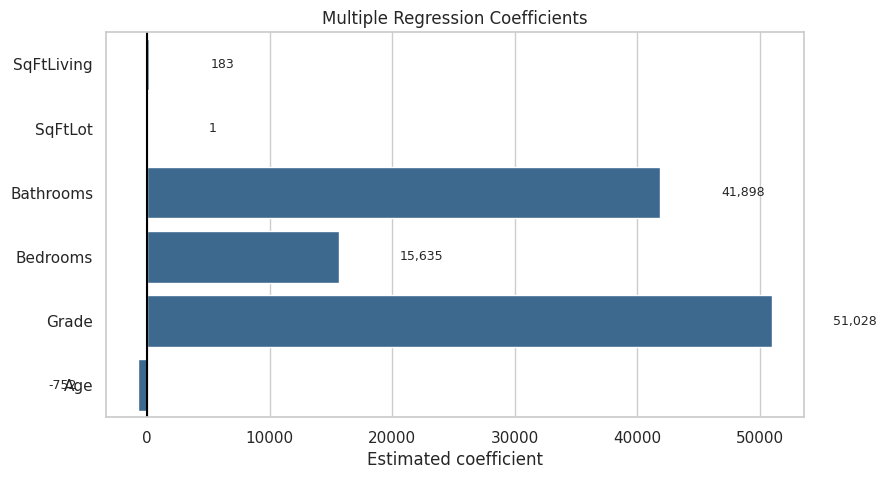

Caption — Setiap koefisien menggambarkan perubahan rata-rata target untuk satu unit perubahan predictor, dengan predictor lain dikendalikan.


In [7]:
fig,ax=plt.subplots()
sns.barplot(data=coef,x="Coefficient",y="Predictor",color="#2F6B9A",ax=ax)
ax.axvline(0,color="black"); ax.set(title="Multiple Regression Coefficients",xlabel="Estimated coefficient",ylabel="")
for bar,v in zip(ax.patches,coef.Coefficient):
    ax.text(v+(5000 if v>=0 else -5000),bar.get_y()+bar.get_height()/2,f"{v:,.0f}",
            va="center",ha="left" if v>=0 else "right",fontsize=9)
plt.show()
print("Caption — Setiap koefisien menggambarkan perubahan rata-rata target untuk satu unit perubahan predictor, dengan predictor lain dikendalikan.")



## 5. Assessing the Model
**MAE** mengukur error absolut rata-rata, **RMSE** lebih sensitif terhadap error besar, sedangkan **R²** mengukur proporsi variasi target yang dijelaskan model pada data evaluasi.



In [8]:
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.2,random_state=42)
mt=LinearRegression().fit(Xtr,ytr); yp=mt.predict(Xte)
print(f"Test MAE={mean_absolute_error(yte,yp):,.0f}")
print(f"Test RMSE={np.sqrt(mean_squared_error(yte,yp)):,.0f}")
print(f"Test R²={r2_score(yte,yp):.4f}")



Test MAE=78,241
Test RMSE=94,890
Test R²=0.7067


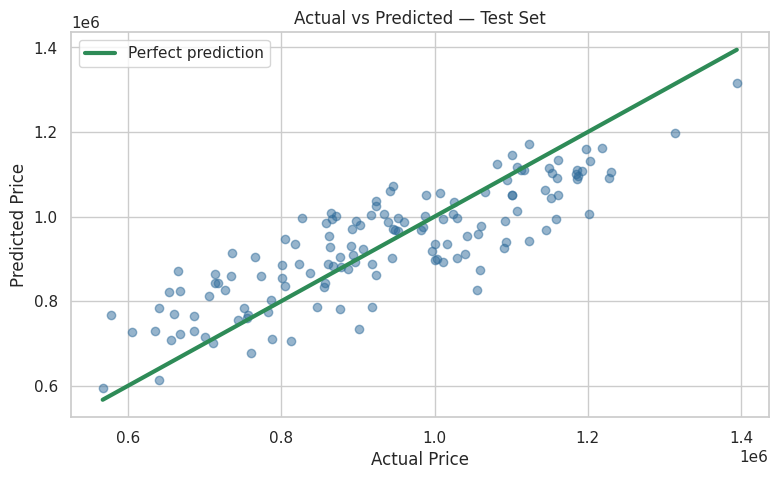

Caption — Titik yang dekat garis hijau memiliki prediction error kecil.


In [9]:
fig,ax=plt.subplots()
ax.scatter(yte,yp,alpha=.5,color="#2F6B9A")
lims=[min(yte.min(),yp.min()),max(yte.max(),yp.max())]
ax.plot(lims,lims,color="#2E8B57",lw=3,label="Perfect prediction")
ax.set(title="Actual vs Predicted — Test Set",xlabel="Actual Price",ylabel="Predicted Price"); ax.legend()
plt.show(); print("Caption — Titik yang dekat garis hijau memiliki prediction error kecil.")



## 6. Cross-Validation
Cross-validation membagi data menjadi beberapa fold agar performa dapat diuji pada bagian data yang tidak digunakan saat fitting. Ini membantu mengukur generalisasi.



Fold RMSE: [94890. 94579. 88853. 94457. 90028.]
Mean=92,562; SD=2,579


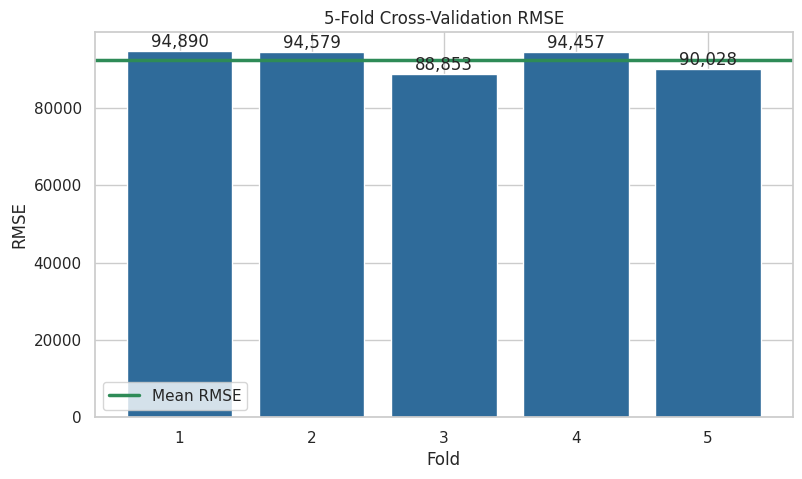

Caption — Variasi antar-fold menunjukkan stabilitas performa model pada subset data yang berbeda.


In [10]:
kf=KFold(n_splits=5,shuffle=True,random_state=42)
cv_rmse=np.sqrt(-cross_val_score(LinearRegression(),X,y,cv=kf,scoring="neg_mean_squared_error"))
print("Fold RMSE:",np.round(cv_rmse,0))
print(f"Mean={cv_rmse.mean():,.0f}; SD={cv_rmse.std():,.0f}")
fig,ax=plt.subplots(); ax.bar(range(1,6),cv_rmse,color="#2F6B9A")
ax.axhline(cv_rmse.mean(),color="#2E8B57",lw=2.5,label="Mean RMSE")
for i,v in enumerate(cv_rmse,1): ax.text(i,v,f"{v:,.0f}",ha="center",va="bottom")
ax.set(title="5-Fold Cross-Validation RMSE",xlabel="Fold",ylabel="RMSE"); ax.legend(); plt.show()
print("Caption — Variasi antar-fold menunjukkan stabilitas performa model pada subset data yang berbeda.")



## 7. Model Selection dan Stepwise Regression
Model yang lebih kompleks tidak selalu memiliki generalisasi lebih baik. Model selection dapat digunakan untuk memilih predictor, tetapi hasilnya tetap perlu divalidasi dan dipertimbangkan bersama pengetahuan domain.



In [11]:
sc=StandardScaler().fit(X)
Xs=sc.transform(X); smod=LinearRegression().fit(Xs,y)
sel=pd.DataFrame({"Predictor":preds,"Std_Coefficient":smod.coef_}).sort_values("Std_Coefficient",key=np.abs,ascending=False)
display(sel)



,Predictor,Std_Coefficient
0,SqFtLiving,98527.157612
4,Grade,85263.687038
2,Bathrooms,30351.931530
3,Bedrooms,22395.092263
5,Age,-19521.057226
1,SqFtLot,5229.553372


## 8. Weighted Regression
Weighted regression memberi bobot berbeda pada observasi ketika fitting. Bobot harus memiliki alasan metodologis, bukan sekadar digunakan untuk memperoleh angka performa yang lebih baik.



In [12]:
w=1+(house.Age.max()-house.Age)/house.Age.max()*2
mw=LinearRegression().fit(X,y,sample_weight=w); yw=mw.predict(X)
print(f"Ordinary RMSE={np.sqrt(mean_squared_error(y,yhat)):,.0f}")
print(f"Weighted RMSE={np.sqrt(mean_squared_error(y,yw)):,.0f}")



Ordinary RMSE=91,758
Weighted RMSE=91,781


## 9. Prediction Using Regression
### Dangers of Extrapolation
Model regression dapat menghasilkan prediksi di luar rentang training, tetapi prediction tersebut adalah **extrapolation** dan dapat tidak reliable.



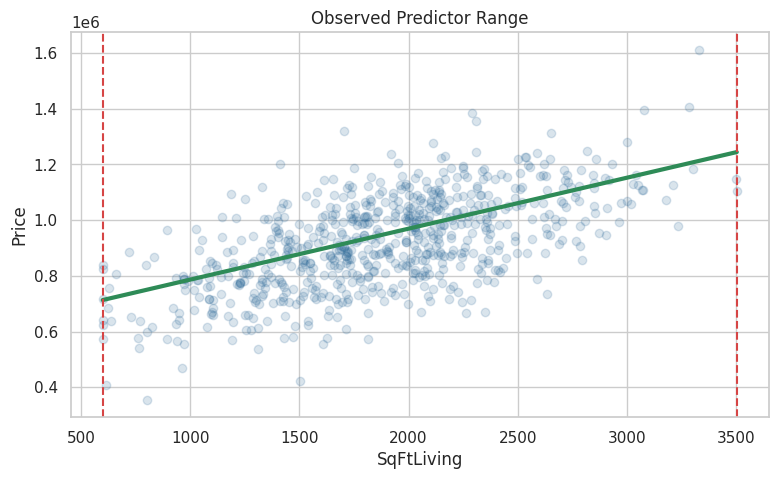

Caption — Batas merah menunjukkan rentang predictor yang tersedia pada training data. Prediction jauh di luar rentang tersebut perlu sangat hati-hati.


In [13]:
xx=np.linspace(house.SqFtLiving.min(),house.SqFtLiving.max(),100)
grid=pd.DataFrame({"SqFtLiving":xx,"SqFtLot":house.SqFtLot.median(),"Bathrooms":house.Bathrooms.median(),
"Bedrooms":house.Bedrooms.median(),"Grade":house.Grade.median(),"Age":house.Age.median()})
pr=ml.predict(grid)
fig,ax=plt.subplots(); ax.scatter(house.SqFtLiving,house.Price,alpha=.18,color="#2F6B9A")
ax.plot(xx,pr,color="#2E8B57",lw=3); ax.axvline(xx.min(),color="#D64545",ls="--"); ax.axvline(xx.max(),color="#D64545",ls="--")
ax.set(title="Observed Predictor Range",xlabel="SqFtLiving",ylabel="Price"); plt.show()
print("Caption — Batas merah menunjukkan rentang predictor yang tersedia pada training data. Prediction jauh di luar rentang tersebut perlu sangat hati-hati.")



### Confidence Interval dan Prediction Interval
Confidence interval menggambarkan ketidakpastian **mean response**, sedangkan prediction interval untuk observasi individual lebih lebar karena memasukkan variasi residual.



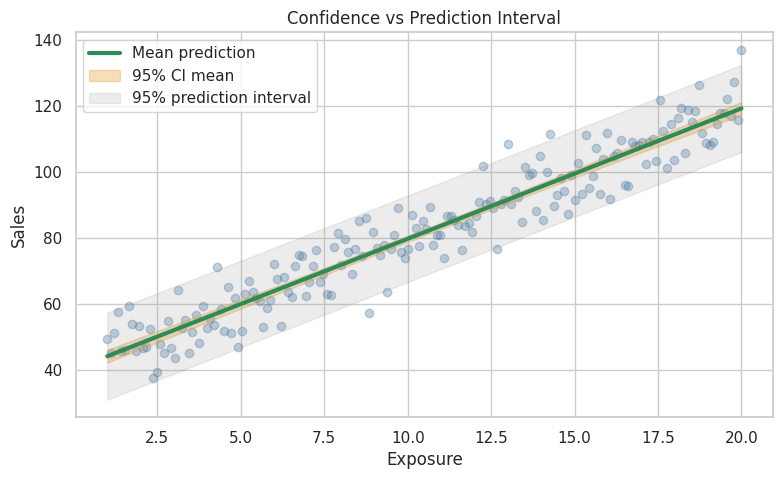

Caption — Prediction interval lebih lebar karena memperhitungkan ketidakpastian mean sekaligus variasi observasi individual.


In [14]:
g=pd.DataFrame({"Exposure":np.linspace(df.Exposure.min(),df.Exposure.max(),100)})
sf=ols.get_prediction(g).summary_frame(alpha=.05)
fig,ax=plt.subplots(); ax.scatter(df.Exposure,df.Sales,alpha=.3,color="#2F6B9A")
ax.plot(g.Exposure,sf["mean"],color="#2E8B57",lw=3,label="Mean prediction")
ax.fill_between(g.Exposure,sf["mean_ci_lower"],sf["mean_ci_upper"],color="#E6A23C",alpha=.35,label="95% CI mean")
ax.fill_between(g.Exposure,sf["obs_ci_lower"],sf["obs_ci_upper"],color="#999999",alpha=.18,label="95% prediction interval")
ax.set(title="Confidence vs Prediction Interval",xlabel="Exposure",ylabel="Sales"); ax.legend(); plt.show()
print("Caption — Prediction interval lebih lebar karena memperhitungkan ketidakpastian mean sekaligus variasi observasi individual.")



## 10. Factor Variables in Regression
### Dummy Variables Representation
Variabel kategorikal dapat diubah menjadi dummy variables. Dengan K kategori, penggunaan K−1 dummy membuat satu kategori menjadi **reference category**. Koefisien dummy dibaca relatif terhadap reference tersebut.



,Predictor,Coefficient
0,SqFtLiving,180.615630
1,Grade,51069.290674
2,PropertyType_Single Family,15550.017018
3,PropertyType_Townhouse,18376.448836


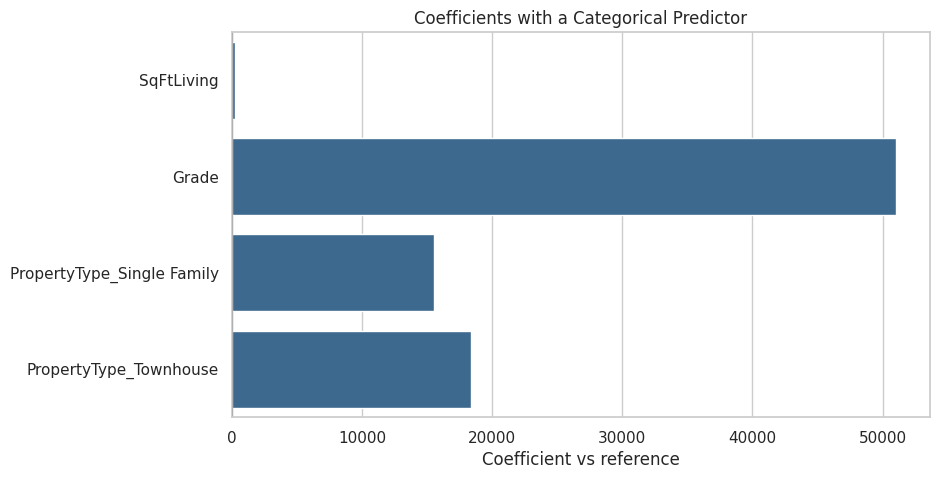

Caption — Koefisien kategori harus selalu dibaca terhadap kategori referensi.


In [15]:
f=house.copy(); f["PropertyType"]=rng.choice(["Single Family","Townhouse","Condo"],len(f),p=[.60,.25,.15])
XF=pd.get_dummies(f[["SqFtLiving","Grade","PropertyType"]],drop_first=True,dtype=int)
fm=LinearRegression().fit(XF,f.Price)
fc=pd.DataFrame({"Predictor":XF.columns,"Coefficient":fm.coef_}); display(fc)
fig,ax=plt.subplots(); sns.barplot(data=fc,x="Coefficient",y="Predictor",color="#2F6B9A",ax=ax)
ax.axvline(0,color="black"); ax.set(title="Coefficients with a Categorical Predictor",xlabel="Coefficient vs reference",ylabel=""); plt.show()
print("Caption — Koefisien kategori harus selalu dibaca terhadap kategori referensi.")



### Factor Variables with Many Levels
Kategori dengan banyak level dapat menghasilkan banyak parameter dan meningkatkan risiko overfitting. Pengelompokan level harus memiliki dasar yang dapat dipertanggungjawabkan.

### Ordered Factor Variables
Kategori berurutan dapat diperlakukan sebagai ordered/numeric factor jika asumsi tentang urutan dan jaraknya masuk akal.



## 11. Correlated Predictors
### Multicollinearity
Multicollinearity terjadi ketika predictor saling berkorelasi kuat. Dampaknya dapat berupa koefisien yang tidak stabil dan interpretasi individual predictor yang sulit.



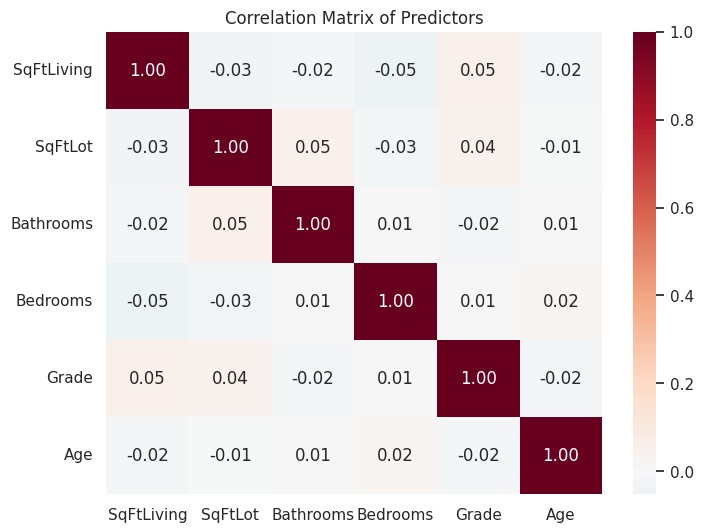

,Predictor,VIF
1,SqFtLiving,1.007689
2,SqFtLot,1.006930
3,Bathrooms,1.003819
4,Bedrooms,1.003963
5,Grade,1.005589
6,Age,1.001114


Caption — Heatmap menunjukkan korelasi antar-predictor; VIF membantu diagnosis multicollinearity lebih lanjut.


In [16]:
corr=house[preds].corr()
fig,ax=plt.subplots(figsize=(8,6)); sns.heatmap(corr,annot=True,fmt=".2f",cmap="RdBu_r",center=0,ax=ax)
ax.set_title("Correlation Matrix of Predictors"); plt.show()
v=sm.add_constant(house[preds])
vif=pd.DataFrame({"Predictor":v.columns,"VIF":[variance_inflation_factor(v.values,i) for i in range(v.shape[1])]})
display(vif[vif.Predictor!="const"])
print("Caption — Heatmap menunjukkan korelasi antar-predictor; VIF membantu diagnosis multicollinearity lebih lanjut.")



### Confounding Variables
Confounding terjadi ketika hubungan predictor–outcome dipengaruhi variabel lain. Multiple regression dapat membantu mengontrol confounder yang terukur, tetapi tidak otomatis menghilangkan confounding yang tidak terukur.

### Interactions and Main Effects
Interaction berarti efek satu predictor bergantung pada predictor lain:
$$Y=b_0+b_1X_1+b_2X_2+b_3X_1X_2+\epsilon$$



                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                              3.504e+05   2.85e+04     12.308      0.000    2.95e+05    4.06e+05
C(GradeGroup)[T.Medium]                1.039e+05   3.22e+04      3.225      0.001    4.07e+04    1.67e+05
C(GradeGroup)[T.High]                  1.616e+05   3.31e+04      4.880      0.000    9.66e+04    2.27e+05
C(GradeGroup)[T.Very High]            -1.295e-08   9.06e-09     -1.429      0.153   -3.07e-08    4.84e-09
SqFtLiving                              177.6940     11.828     15.024      0.000     154.472     200.916
SqFtLiving:C(GradeGroup)[T.Medium]        5.5950     16.645      0.336      0.737     -27.086      38.275
SqFtLiving:C(GradeGroup)[T.High]         18.8515     16.827      1.120      0.263     -14.186      51.889
SqFtLiving:C(GradeGroup)[T.Very High] -4.078e-

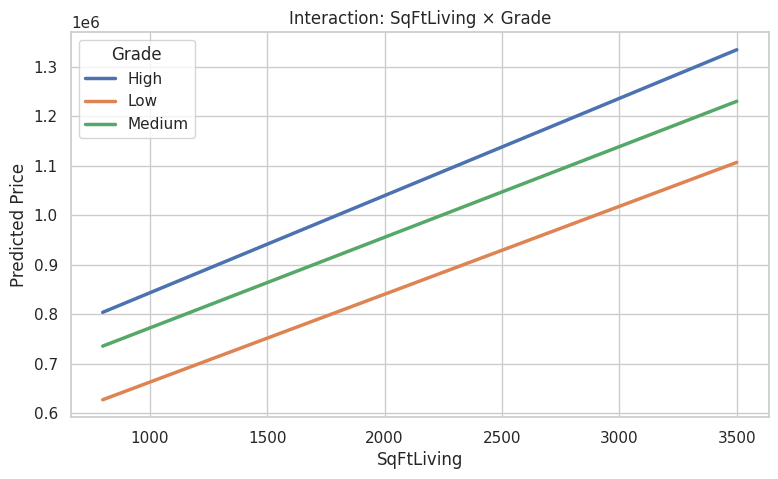

Caption — Kemiringan garis yang berbeda menunjukkan bahwa efek SqFtLiving berubah menurut GradeGroup.


In [17]:
f["GradeGroup"]=pd.cut(f.Grade,[4,6,8,10,11],labels=["Low","Medium","High","Very High"],include_lowest=True)
im=smf.ols("Price ~ SqFtLiving*C(GradeGroup)+SqFtLot+Bathrooms+Bedrooms+Age",data=f).fit()
print(im.summary().tables[1])
grid=pd.DataFrame({"SqFtLiving":np.tile(np.linspace(800,3500,60),3),"GradeGroup":np.repeat(["Low","Medium","High"],60),
"SqFtLot":house.SqFtLot.median(),"Bathrooms":house.Bathrooms.median(),"Bedrooms":house.Bedrooms.median(),"Age":house.Age.median()})
grid["PredictedPrice"]=im.predict(grid)
fig,ax=plt.subplots()
for g,grp in grid.groupby("GradeGroup"): ax.plot(grp.SqFtLiving,grp.PredictedPrice,lw=2.5,label=g)
ax.set(title="Interaction: SqFtLiving × Grade",xlabel="SqFtLiving",ylabel="Predicted Price"); ax.legend(title="Grade"); plt.show()
print("Caption — Kemiringan garis yang berbeda menunjukkan bahwa efek SqFtLiving berubah menurut GradeGroup.")



## 12. Regression Diagnostics
Diagnostics memeriksa apakah residual dan observasi tertentu menunjukkan masalah model: **outliers, influential values, heteroskedasticity, non-normality, correlated errors, dan nonlinearity**.



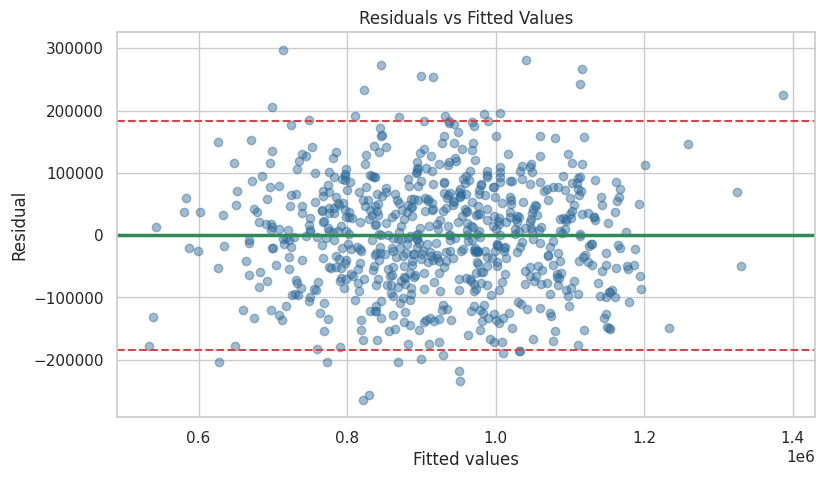

Caption — Residual idealnya menyebar acak di sekitar nol. Pola kurva atau funnel dapat mengindikasikan nonlinearity atau heteroskedasticity.


In [18]:
dm=smf.ols("Price ~ SqFtLiving+SqFtLot+Bathrooms+Bedrooms+Grade+Age",data=house).fit()
d=house.copy(); d["Fitted"]=dm.fittedvalues; d["Residual"]=dm.resid
d["StdResidual"]=dm.get_influence().resid_studentized_internal
fig,ax=plt.subplots(); ax.scatter(d.Fitted,d.Residual,alpha=.45,color="#2F6B9A")
ax.axhline(0,color="#2E8B57",lw=2.5); ax.axhline(2*d.Residual.std(),color="#D64545",ls="--"); ax.axhline(-2*d.Residual.std(),color="#D64545",ls="--")
ax.set(title="Residuals vs Fitted Values",xlabel="Fitted values",ylabel="Residual"); plt.show()
print("Caption — Residual idealnya menyebar acak di sekitar nol. Pola kurva atau funnel dapat mengindikasikan nonlinearity atau heteroskedasticity.")



### Outliers
Outlier adalah observasi yang menyimpang dari pola umum. Jangan langsung menghapusnya; periksa validitas dan konteksnya.

### Influential Values
Observasi influential memiliki pengaruh besar terhadap hasil fitting. Cook's distance adalah salah satu ukuran diagnosis.



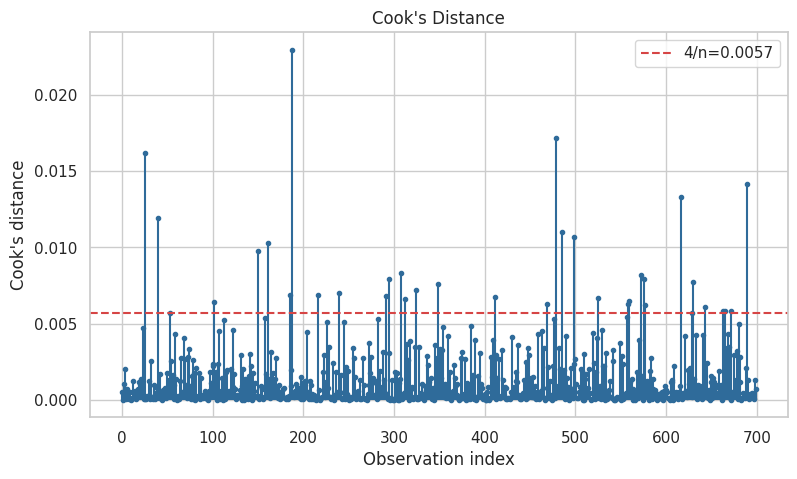

Caption — Nilai Cook's distance yang relatif besar perlu diperiksa karena observasi tersebut dapat memengaruhi model.


In [19]:
cooks=dm.get_influence().cooks_distance[0]
fig,ax=plt.subplots(); ax.stem(np.arange(len(cooks)),cooks,linefmt="#2F6B9A",markerfmt=".",basefmt=" ")
ax.axhline(4/len(cooks),color="#D64545",ls="--",label=f"4/n={4/len(cooks):.4f}")
ax.set(title="Cook's Distance",xlabel="Observation index",ylabel="Cook's distance"); ax.legend(); plt.show()
print("Caption — Nilai Cook's distance yang relatif besar perlu diperiksa karena observasi tersebut dapat memengaruhi model.")



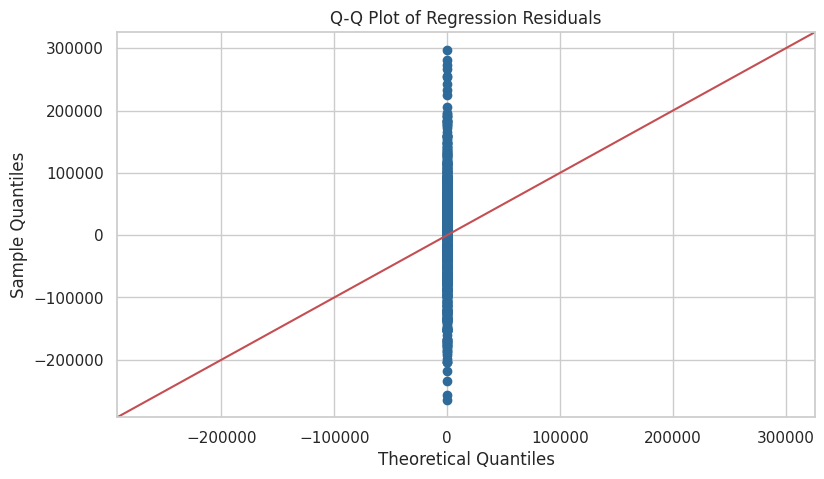

Caption — Q-Q plot digunakan untuk melihat kesesuaian distribusi residual dengan normalitas secara visual.


In [20]:
fig,ax=plt.subplots(); sm.qqplot(dm.resid,line="45",ax=ax,markerfacecolor="#2F6B9A",markeredgecolor="#2F6B9A")
ax.set_title("Q-Q Plot of Regression Residuals"); plt.show()
print("Caption — Q-Q plot digunakan untuk melihat kesesuaian distribusi residual dengan normalitas secara visual.")



### Partial Residual Plots dan Nonlinearity
Partial residual membantu melihat pola hubungan predictor tertentu setelah mempertimbangkan predictor lain. Pola melengkung dapat menjadi alasan untuk mempertimbangkan polynomial atau spline.



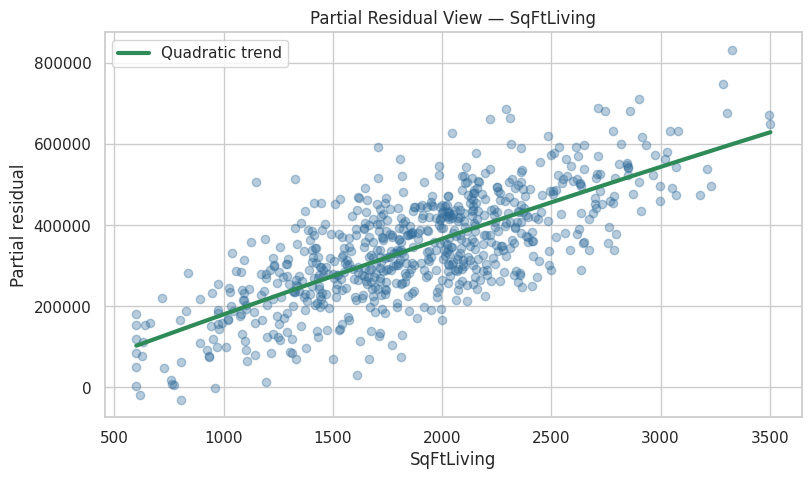

Caption — Kurva membantu mengidentifikasi kemungkinan hubungan nonlinear.


In [21]:
partial=dm.resid+dm.params["SqFtLiving"]*house.SqFtLiving
z=np.polyfit(house.SqFtLiving,partial,2); xx=np.linspace(house.SqFtLiving.min(),house.SqFtLiving.max(),200)
fig,ax=plt.subplots(); ax.scatter(house.SqFtLiving,partial,alpha=.35,color="#2F6B9A")
ax.plot(xx,np.polyval(z,xx),color="#2E8B57",lw=3,label="Quadratic trend")
ax.set(title="Partial Residual View — SqFtLiving",xlabel="SqFtLiving",ylabel="Partial residual"); ax.legend(); plt.show()
print("Caption — Kurva membantu mengidentifikasi kemungkinan hubungan nonlinear.")



## 13. Polynomial Regression
Polynomial regression menambahkan pangkat predictor, misalnya:
$$Y=b_0+b_1X+b_2X^2+\epsilon$$
Model tetap linear terhadap koefisien tetapi dapat membentuk kurva.



/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


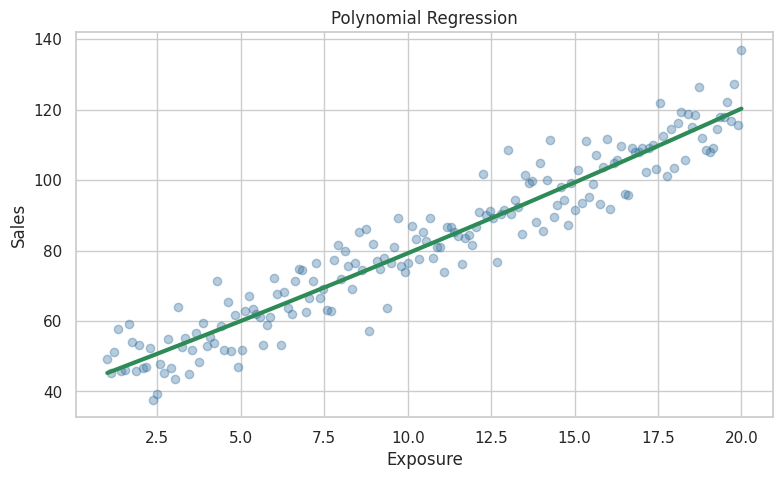

Caption — Term kuadrat memungkinkan model menangkap hubungan melengkung yang tidak dapat ditangkap satu garis lurus.


In [22]:
pf=PolynomialFeatures(2,include_bias=False); xp=pf.fit_transform(df[["Exposure"]]); pm=LinearRegression().fit(xp,df.Sales)
xx=np.linspace(1,20,300).reshape(-1,1); yy=pm.predict(pf.transform(xx))
fig,ax=plt.subplots(); ax.scatter(df.Exposure,df.Sales,alpha=.35,color="#2F6B9A"); ax.plot(xx,yy,color="#2E8B57",lw=3)
ax.set(title="Polynomial Regression",xlabel="Exposure",ylabel="Sales"); plt.show()
print("Caption — Term kuadrat memungkinkan model menangkap hubungan melengkung yang tidak dapat ditangkap satu garis lurus.")



## 14. Splines
Spline menggunakan beberapa fungsi polynomial yang disambungkan secara smooth. Pendekatan ini fleksibel tanpa harus menggunakan satu polynomial berderajat tinggi.



/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(


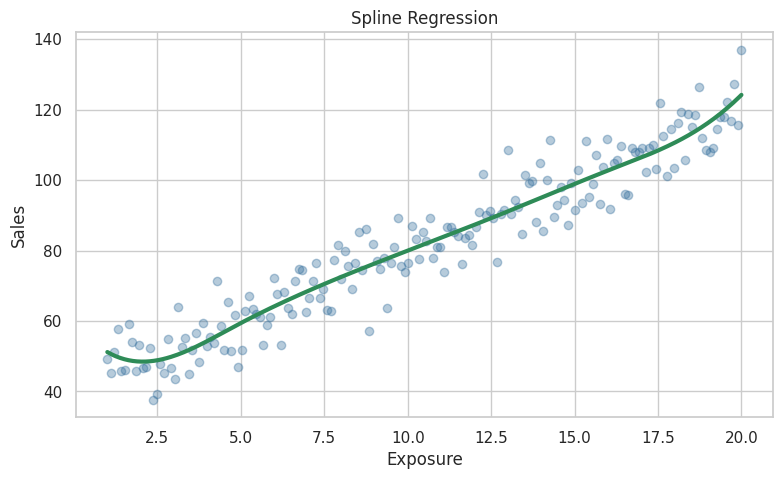

Caption — Spline dapat mengikuti perubahan pola secara lokal sehingga lebih fleksibel daripada satu garis linear.


In [23]:
st=SplineTransformer(n_knots=6,degree=3,include_bias=False); xs=st.fit_transform(df[["Exposure"]]); smod=LinearRegression().fit(xs,df.Sales)
xx=np.linspace(1,20,300).reshape(-1,1); yy=smod.predict(st.transform(xx))
fig,ax=plt.subplots(); ax.scatter(df.Exposure,df.Sales,alpha=.35,color="#2F6B9A"); ax.plot(xx,yy,color="#2E8B57",lw=3)
ax.set(title="Spline Regression",xlabel="Exposure",ylabel="Sales"); plt.show()
print("Caption — Spline dapat mengikuti perubahan pola secara lokal sehingga lebih fleksibel daripada satu garis linear.")



## 15. Generalized Additive Models (GAM)
GAM memodelkan target sebagai penjumlahan fungsi predictor:
$$Y=b_0+f_1(X_1)+f_2(X_2)+...+\epsilon$$
GAM mempertahankan interpretabilitas komponen sambil memungkinkan hubungan nonlinear.



GAM-like RMSE=95,765


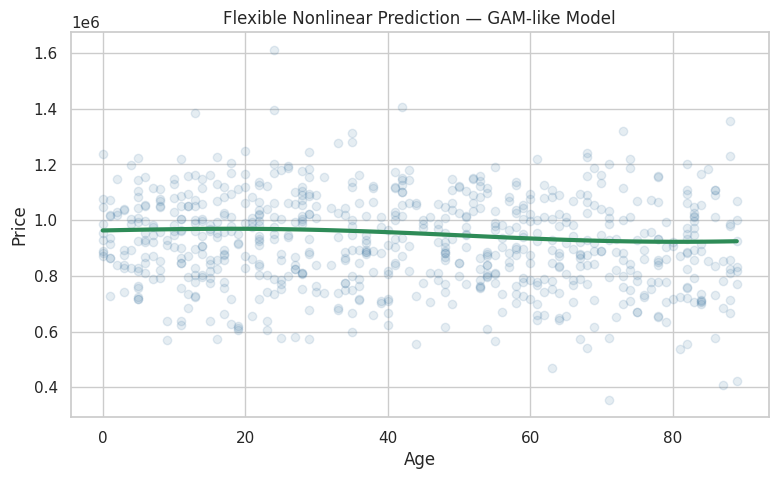

Caption — Pendekatan spline additive dapat menangkap pola nonlinear tanpa memaksakan satu garis lurus pada seluruh rentang predictor.


In [24]:
features=["SqFtLiving","Age","SqFtLot","Bathrooms","Bedrooms","Grade"]
pre=ColumnTransformer([
("living",SplineTransformer(n_knots=6,degree=3,include_bias=False),["SqFtLiving"]),
("age",SplineTransformer(n_knots=5,degree=3,include_bias=False),["Age"]),
("linear","passthrough",["SqFtLot","Bathrooms","Bedrooms","Grade"])])
gam=Pipeline([("features",pre),("model",Ridge(alpha=10))]).fit(house[features],house.Price)
gp=gam.predict(house[features])
print(f"GAM-like RMSE={np.sqrt(mean_squared_error(house.Price,gp)):,.0f}")
age=np.linspace(house.Age.min(),house.Age.max(),100)
g=pd.DataFrame({"SqFtLiving":house.SqFtLiving.median(),"Age":age,"SqFtLot":house.SqFtLot.median(),
"Bathrooms":house.Bathrooms.median(),"Bedrooms":house.Bedrooms.median(),"Grade":house.Grade.median()})
fig,ax=plt.subplots(); ax.plot(age,gam.predict(g),color="#2E8B57",lw=3); ax.scatter(house.Age,house.Price,alpha=.12,color="#2F6B9A")
ax.set(title="Flexible Nonlinear Prediction — GAM-like Model",xlabel="Age",ylabel="Price"); plt.show()
print("Caption — Pendekatan spline additive dapat menangkap pola nonlinear tanpa memaksakan satu garis lurus pada seluruh rentang predictor.")



## 16. Kaitan dengan Machine Learning dan Deep Learning
Regression merupakan bentuk **supervised learning**: model belajar dari features dengan target yang diketahui. Konsep chapter ini menjadi fondasi ML/DL:
- predictor → feature/input;
- response → target/output;
- residual/loss → error;
- train/test & cross-validation → evaluasi generalisasi;
- diagnostics → error analysis;
- regularization → pengendalian kompleksitas;
- nonlinear regression → konsep yang diperluas neural networks.

Deep learning dapat mempelajari hubungan nonlinear yang jauh lebih kompleks, tetapi prinsip evaluasi out-of-sample, error analysis, dan pencegahan data leakage tetap penting.



## 17. Summary
1. Simple regression memodelkan satu predictor dan satu response.
2. Multiple regression memungkinkan banyak predictor.
3. Fitted values dan residual membantu memahami error.
4. MAE, RMSE, dan R² memberi sudut pandang berbeda.
5. Cross-validation membantu menilai generalisasi.
6. Dummy variables digunakan untuk factor variables.
7. Multicollinearity dapat membuat koefisien tidak stabil.
8. Interaction menunjukkan ketergantungan efek antar-predictor.
9. Diagnostics penting untuk outlier, influence, heteroskedasticity, dan nonlinearity.
10. Polynomial, spline, dan GAM memperluas regression untuk hubungan nonlinear.

**Takeaway:** regression bukan hanya mencari garis terbaik, tetapi membangun model yang dapat dijelaskan, didiagnosis, dan diuji pada data yang belum pernah dilihat model.

